In [22]:
import mysql.connector
from credenciales import mysql_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import plotly.express as px
import plotly.io as pio
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import IsolationForest

In [2]:
#Creación del nuevo dataframe.
conn = mysql.connector.connect(**mysql_config)

---
## Extracción del dataset analítico

In [5]:
query = """
SELECT
    e.Cultivo,
    e.Provincia,
    e.Anio,
    e.Hectareas,
    a.Temp_media,
    a.Temp_min,
    a.Temp_max,
    a.Precipitacion,
    f.Area,
    f.Producto,
    f.Elemento,
    f.Valor,
    n.PRECTOTCORR,
    n.T2M,
    n.T2M_MAX,
    n.T2M_MIN
FROM ESYRCE e
JOIN AEMET a 
    ON e.Anio = a.anio
    AND LOWER(e.Provincia) = LOWER(a.Provincia)
JOIN NASA n 
    ON e.Anio = n.YEAR
JOIN FAOSTAT f 
    ON e.Anio = f.Anio
WHERE e.Provincia IN ('VALLADOLID', 'LA RIOJA', 'JAEN', 'VALENCIA')
"""

df_agric_clima = pd.read_sql(query, conn)
conn.close()

df_agric_clima.head()

/var/folders/gk/7whljmd13_gckymc1r2zhl800000gn/T/ipykernel_1386/3642382072.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_agric_clima = pd.read_sql(query, conn)


,Cultivo,Provincia,Anio,Hectareas,Temp_media,Temp_min,Temp_max,Precipitacion,Area,Producto,Elemento,Valor,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN
0,BARBECHO,VALENCIA,2005,17620.39,18.004383,13.51589,22.491234,345.2,España,Zanahorias y nabos,Área cosechada,17535.0,0.9,13.34,39.85,-8.9
1,BARBECHO,VALENCIA,2005,17620.39,18.004383,13.51589,22.491234,345.2,España,Zanahorias y nabos,Rendimiento,32681.3,0.9,13.34,39.85,-8.9
2,BARBECHO,VALENCIA,2005,17620.39,18.004383,13.51589,22.491234,345.2,España,Zanahorias y nabos,Producción,573067.0,0.9,13.34,39.85,-8.9
3,BARBECHO,VALENCIA,2005,17620.39,18.004383,13.51589,22.491234,345.2,España,Vino,Producción,3643700.0,0.9,13.34,39.85,-8.9
4,BARBECHO,VALENCIA,2005,17620.39,18.004383,13.51589,22.491234,345.2,España,Veza,Área cosechada,142100.0,0.9,13.34,39.85,-8.9


In [6]:
df_agric_clima.to_parquet('dataset_analitico_parquet')
df_agric_clima = pd.read_parquet('dataset_analitico_parquet')

---
## EDA

In [7]:
#Reorganización de columnas para que tengan un orden más lógico
df_agric_clima = df_agric_clima[[
    "Area", "Anio", "Provincia", "Elemento","Producto", "Cultivo", 
    "Hectareas", "Valor", "Temp_media", "Temp_min", "Temp_max",
    "Precipitacion", "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"
]]

df_agric_clima.head()

,Area,Anio,Provincia,Elemento,Producto,Cultivo,Hectareas,Valor,Temp_media,Temp_min,Temp_max,Precipitacion,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN
0,España,2005,VALENCIA,Área cosechada,Zanahorias y nabos,BARBECHO,17620.39,17535.0,18.004383,13.51589,22.491234,345.2,0.9,13.34,39.85,-8.9
1,España,2005,VALENCIA,Rendimiento,Zanahorias y nabos,BARBECHO,17620.39,32681.3,18.004383,13.51589,22.491234,345.2,0.9,13.34,39.85,-8.9
2,España,2005,VALENCIA,Producción,Zanahorias y nabos,BARBECHO,17620.39,573067.0,18.004383,13.51589,22.491234,345.2,0.9,13.34,39.85,-8.9
3,España,2005,VALENCIA,Producción,Vino,BARBECHO,17620.39,3643700.0,18.004383,13.51589,22.491234,345.2,0.9,13.34,39.85,-8.9
4,España,2005,VALENCIA,Área cosechada,Veza,BARBECHO,17620.39,142100.0,18.004383,13.51589,22.491234,345.2,0.9,13.34,39.85,-8.9


In [8]:
#Exploración del dataframe analítico.
df_agric_clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 1481904 entries, 0 to 1481903
Data columns (total 16 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Area           1481904 non-null  str    
 1   Anio           1481904 non-null  int64  
 2   Provincia      1481904 non-null  str    
 3   Elemento       1481904 non-null  str    
 4   Producto       1481904 non-null  str    
 5   Cultivo        1481904 non-null  str    
 6   Hectareas      1019444 non-null  float64
 7   Valor          1461573 non-null  float64
 8   Temp_media     1481904 non-null  float64
 9   Temp_min       1481904 non-null  float64
 10  Temp_max       1481904 non-null  float64
 11  Precipitacion  1481904 non-null  float64
 12  PRECTOTCORR    1481904 non-null  float64
 13  T2M            1481904 non-null  float64
 14  T2M_MAX        1481904 non-null  float64
 15  T2M_MIN        1481904 non-null  float64
dtypes: float64(10), int64(1), str(5)
memory usage: 265.9 MB


In [9]:
#Hay casi un 1,5 millones de filas. 
#Agrupo los cultivos que me interesan, ya que revisarlos todos sería demasiado extenso para un primer análisis.

cultivos_esyrce = [
    "TRIGO DURO", "TRIGO BLANDO Y SEMIDURO", "CEBADA DE 2 CARRERAS", 
    "CEBADA DE 6 CARRERAS", "AVENA", "MAIZ", "TRITICALE",
    "ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA",
    "UVA DE MESA NO ESPECIFIC", "UVA DE TRANSFORMACION",
    "NARANJO", "MANDARINO", "LIMONERO", "NARANJO AMARGO"
]

productos_faostat = [
    "Trigo", "Maíz", "Triticale",
    "Aceitunas, olivas",
    "Uvas",
    "Naranjas", "Limones y limas", "Tangerinas, mandarinas, clementinas"
]

df_agric_clima_filtrado = df_agric_clima[
    (df_agric_clima["Cultivo"].isin(cultivos_esyrce)) &
    (df_agric_clima["Producto"].isin(productos_faostat))
]

print(len(df_agric_clima_filtrado))

12480


In [10]:
#Guardo el df filtrado, con un número de filas más adecuado.
df_agric_clima = df_agric_clima_filtrado.copy()
df_agric_clima.to_parquet('dataset_analitico_filtrado.parquet')
print(df_agric_clima.shape)

(12480, 16)


In [11]:
#Nueva exploración de datos tras el filtro.
df_agric_clima.info()

<class 'pandas.DataFrame'>
Index: 12480 entries, 1031 to 937905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           12480 non-null  str    
 1   Anio           12480 non-null  int64  
 2   Provincia      12480 non-null  str    
 3   Elemento       12480 non-null  str    
 4   Producto       12480 non-null  str    
 5   Cultivo        12480 non-null  str    
 6   Hectareas      10944 non-null  float64
 7   Valor          12480 non-null  float64
 8   Temp_media     12480 non-null  float64
 9   Temp_min       12480 non-null  float64
 10  Temp_max       12480 non-null  float64
 11  Precipitacion  12480 non-null  float64
 12  PRECTOTCORR    12480 non-null  float64
 13  T2M            12480 non-null  float64
 14  T2M_MAX        12480 non-null  float64
 15  T2M_MIN        12480 non-null  float64
dtypes: float64(10), int64(1), str(5)
memory usage: 2.3 MB


In [12]:
#Revisión de nulos
(df_agric_clima.isnull().sum()/len(df_agric_clima))*100

Area              0.000000
Anio              0.000000
Provincia         0.000000
Elemento          0.000000
Producto          0.000000
Cultivo           0.000000
Hectareas        12.307692
Valor             0.000000
Temp_media        0.000000
Temp_min          0.000000
Temp_max          0.000000
Precipitacion     0.000000
PRECTOTCORR       0.000000
T2M               0.000000
T2M_MAX           0.000000
T2M_MIN           0.000000
dtype: float64

#### **Distribuciones**

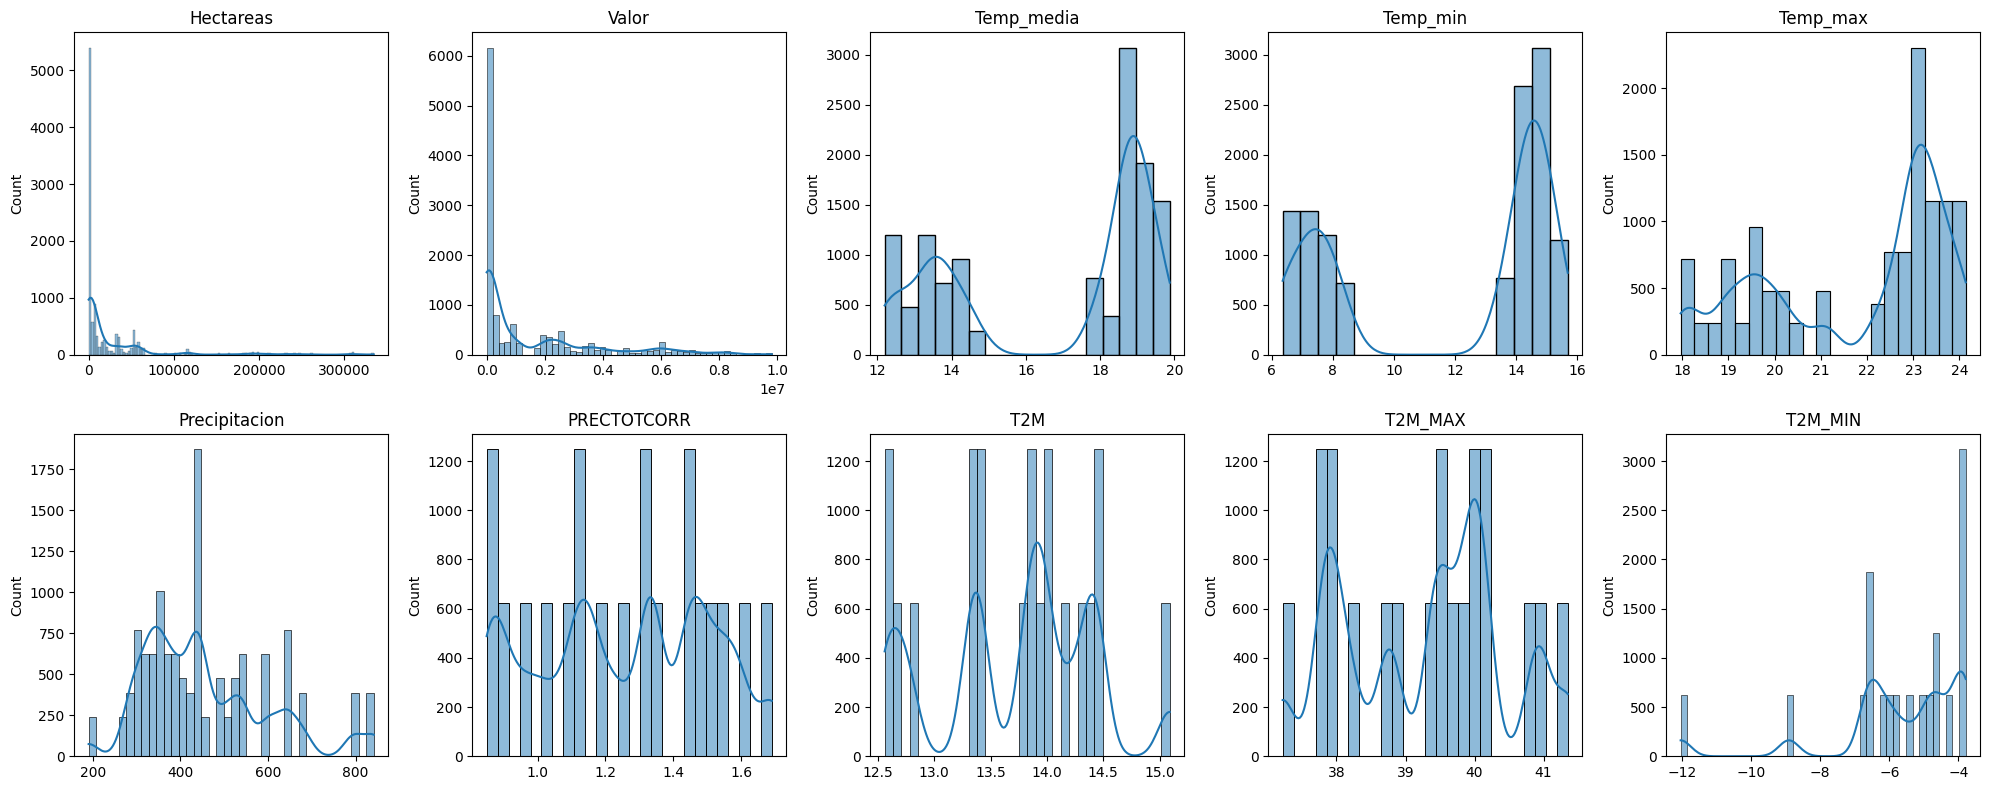

In [16]:
numericas = ["Hectareas", "Valor", "Temp_media", "Temp_min", "Temp_max", 
             "Precipitacion", "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.histplot(df_agric_clima[col].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

##### **Hectáreas y Valor**

Ambas variables presentan una distribución exponencial con cola larga hacia la derecha,parece que es típico de los datos agrícolas, donde unas pocas combinaciones de cultivo y provincia concentran la mayor parte de la superficie cultivada y la producción. Se observan valores extremos en el extremo derecho que serán analizados como posibles outliers.

##### **Temperaturas (Temp_media, Temp_min, Temp_max)**
Las tres variables de temperatura muestran una distribución bimodal, con dos grupos claramente diferenciados. Esto es coherente con la naturaleza de los datos: las provincias de Valencia y Jaén, con clima mediterráneo más cálido, forman un grupo, mientras que Valladolid y Logroño, con clima continental más frío, forman otro. La temperatura máxima presenta una distribución algo más homogénea entre ambos grupos.

##### **Precipitación (AEMET)**
La precipitación tiende hacia la normalidad pero con un pico secundario destacado, posiblemente asociado al patrón de precipitación diferencial de Valencia respecto al resto de provincias.

##### **Variables NASA (PRECTOTCORR, T2M, T2M_MAX, T2M_MIN)**
Estas variables muestran picos muy definidos y regulares, lo que refleja su naturaleza: son datos anuales nacionales que se repiten para cada combinación de cultivo y provincia dentro del mismo año. No representa un problema para el análisis, sino una característica del dato de origen.

In [17]:
estadisticos = pd.DataFrame({
    "Skewness": df_agric_clima[numericas].skew(),
    "Kurtosis": df_agric_clima[numericas].kurtosis()
})

print(estadisticos)

               Skewness   Kurtosis
Hectareas      3.477560  13.435049
Valor          1.585051   1.626306
Temp_media    -0.499166  -1.554380
Temp_min      -0.469428  -1.672098
Temp_max      -0.594056  -1.199066
Precipitacion  0.892589   0.326856
PRECTOTCORR   -0.070249  -1.153128
T2M           -0.170773  -0.695374
T2M_MAX       -0.078617  -1.008878
T2M_MIN       -1.747351   3.266731


#### **Skewness y Kurtosis**

**Hectáreas** destaca con un skewness de 3.48 y kurtosis de 13.4, indicando una 
distribución muy sesgada a la derecha con una cantidad extraordinaria de outliers. 

**Valor** también muestra sesgo positivo moderado (1.59) con colas relativamente normales.

**Temperaturas (AEMET)** presentan sesgo negativo leve y kurtosis negativa, 
lo que confirma la distribución bimodal vista en los histogramas con pocas observaciones 
extremas. Excepción: **T2M_MIN** con kurtosis 3.27 y sesgo -1.75, con colas pesadas y valores extremos hacia temperaturas muy bajas.

**Precipitación (AEMET)** es la única variable climática con sesgo positivo (0.89), 
coherente con el patrón diferencial de Valencia.

**Variables NASA** son las más simétricas, reflejo de su naturaleza como dato 
nacional agregado anual.

#### **Q-Q Plot**
Al estar trabajando con una muestra grande,n > 5000, considero más fiable el uso de este método.

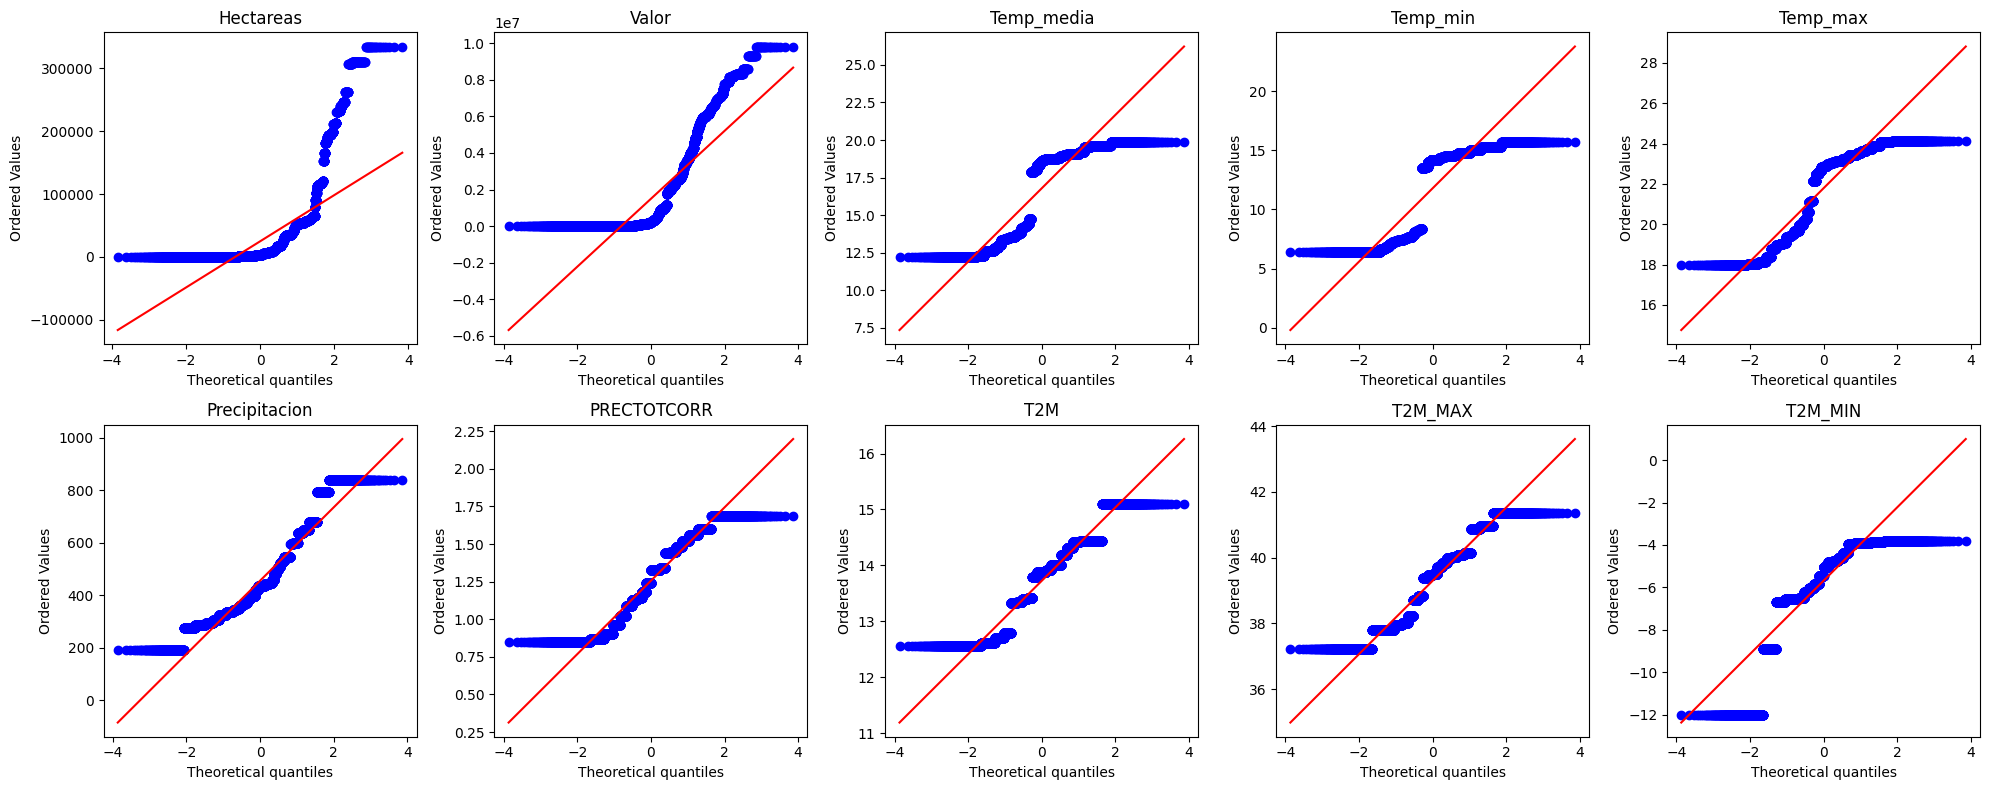

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    datos = df_agric_clima[col].dropna()
    stats.probplot(datos, dist="norm", plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Ninguna variable sigue una distribución normal. Se observan tres patrones principales:

**Hectáreas y Valor** presentan una S muy pronunciada con la cola superior muy alejada de la línea teórica, confirmando el sesgo positivo extremo ya detectado en el skewness y la kurtosis.

**Temperaturas AEMET (Temp_media, Temp_min, Temp_max)** muestran una S con escalones planos que corresponden a los dos grupos climáticos identificados en los histogramas: Valencia y Jaén por un lado, Valladolid y Logroño por otro. Su naturaleza bimodal las aleja de la normalidad.

**Precipitación** es la más próxima a la línea en la zona central pero con los extremos desviados, especialmente el superior, coherente con el patrón diferencial de Valencia.

**Variables NASA (PRECTOTCORR, T2M, T2M_MAX, T2M_MIN)** presentan escalones horizontales muy marcados, reflejo de que son pocos valores distintos (uno por año) repetidos para cada combinación de cultivo y provincia. No tiene sentido testear su normalidad.

#### **Transformación de datos.**

#### Yeo-Johnson.

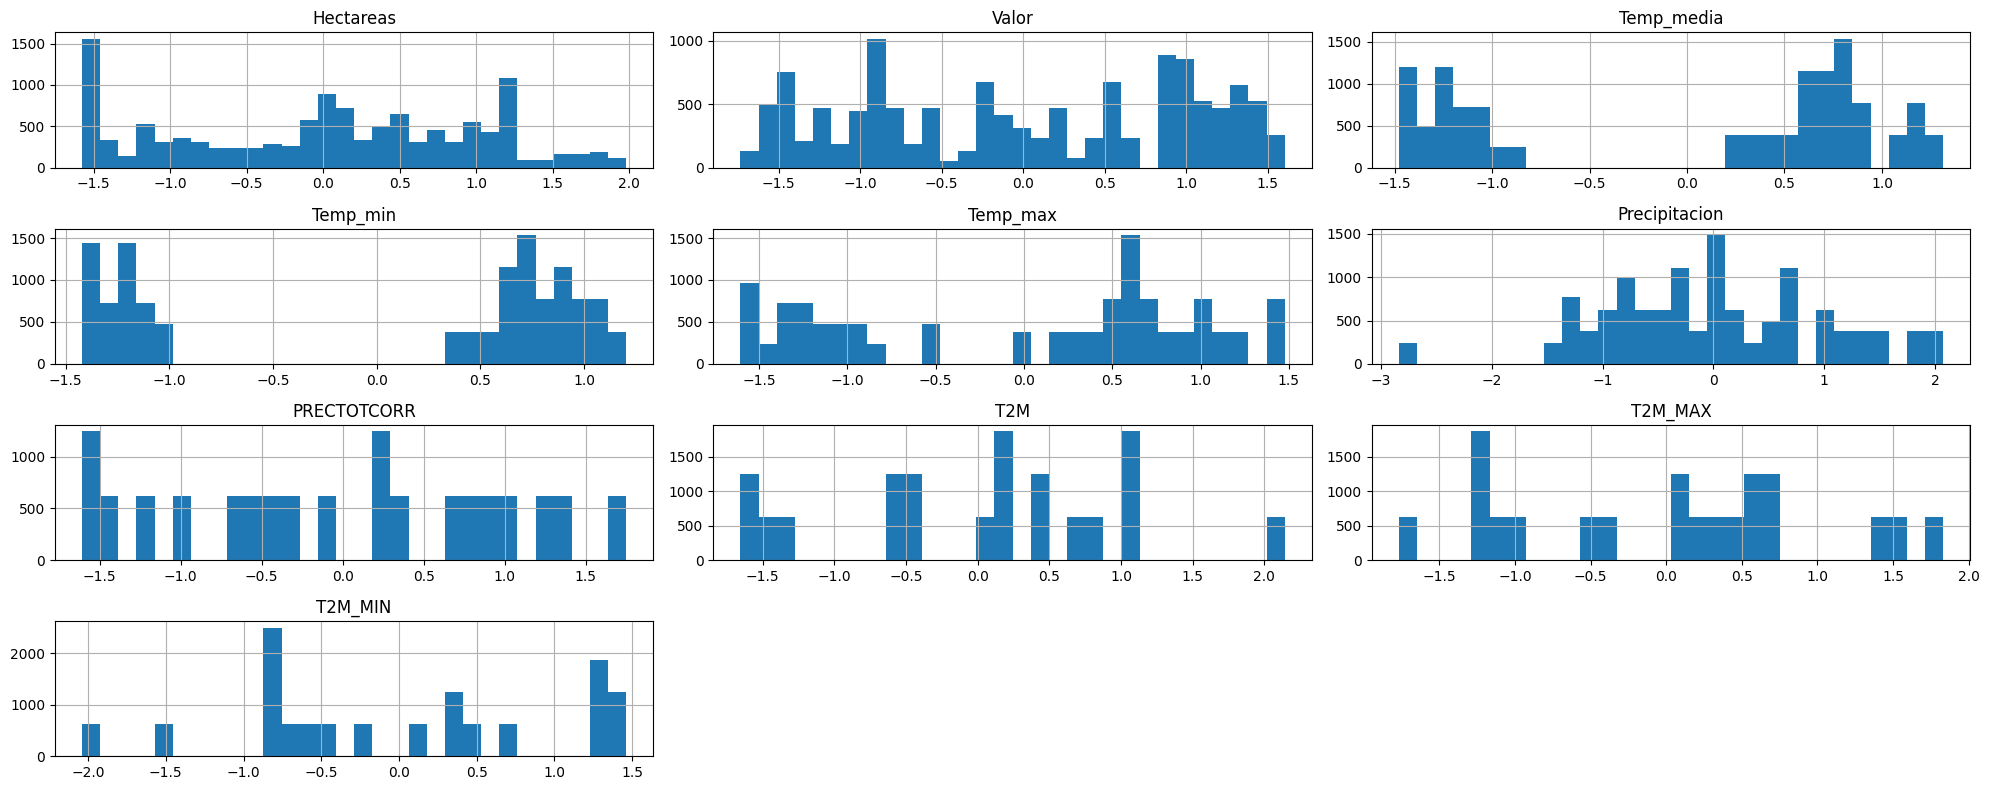

In [19]:
pt = PowerTransformer(method='yeo-johnson')

df_transformado = df_agric_clima.copy()
df_transformado[numericas] = pt.fit_transform(df_agric_clima[numericas].fillna(0))

df_transformado[numericas].hist(figsize=(20, 8), bins=30)
plt.tight_layout()
plt.show()

In [20]:
pd.DataFrame({
    "Skewness_original": df_agric_clima[numericas].skew(),
    "Skewness_transformado": df_transformado[numericas].skew(),
    "Kurtosis_original": df_agric_clima[numericas].kurtosis(),
    "Kurtosis_transformado": df_transformado[numericas].kurtosis()
}).round(3)

,Skewness_original,Skewness_transformado,Kurtosis_original,Kurtosis_transformado
Hectareas,3.478,-0.128,13.435,-1.092
Valor,1.585,-0.072,1.626,-1.399
Temp_media,-0.499,-0.375,-1.554,-1.646
Temp_min,-0.469,-0.417,-1.672,-1.704
Temp_max,-0.594,-0.300,-1.199,-1.445
Precipitacion,0.893,0.001,0.327,0.008
PRECTOTCORR,-0.070,-0.050,-1.153,-1.153
T2M,-0.171,-0.027,-0.695,-0.607
T2M_MAX,-0.079,-0.022,-1.009,-0.992
T2M_MIN,-1.747,-0.120,3.267,-0.936


Se aplicó la transformación Yeo-Johnson a todas las variables numéricas para reducir el sesgo y aproximar las distribuciones a la normalidad.

#### Resultados destacados

- **Hectáreas**: skewness de 3.48 → -0.13 y kurtosis de 13.4 → -1.09. La mayor transformación
- **Valor**: skewness de 1.59 → -0.07. Prácticamente simétrica tras la transformación.
- **T2M_MIN**: skewness de -1.75 → -0.12 y kurtosis de 3.27 → -0.94. 
La variable climática más problemática quedó muy bien resuelta.
- **Precipitación**: skewness de 0.89 → 0.001. Resultado casi perfecto.

#### Limitaciones
Las temperaturas AEMET (Temp_media, Temp_min, Temp_max) mantienen una kurtosis 
negativa elevada porque su naturaleza bimodal, derivada de los dos grupos climáticos 
distintos (Valencia/Jaén vs Valladolid/Logroño).

#### **Outliers**

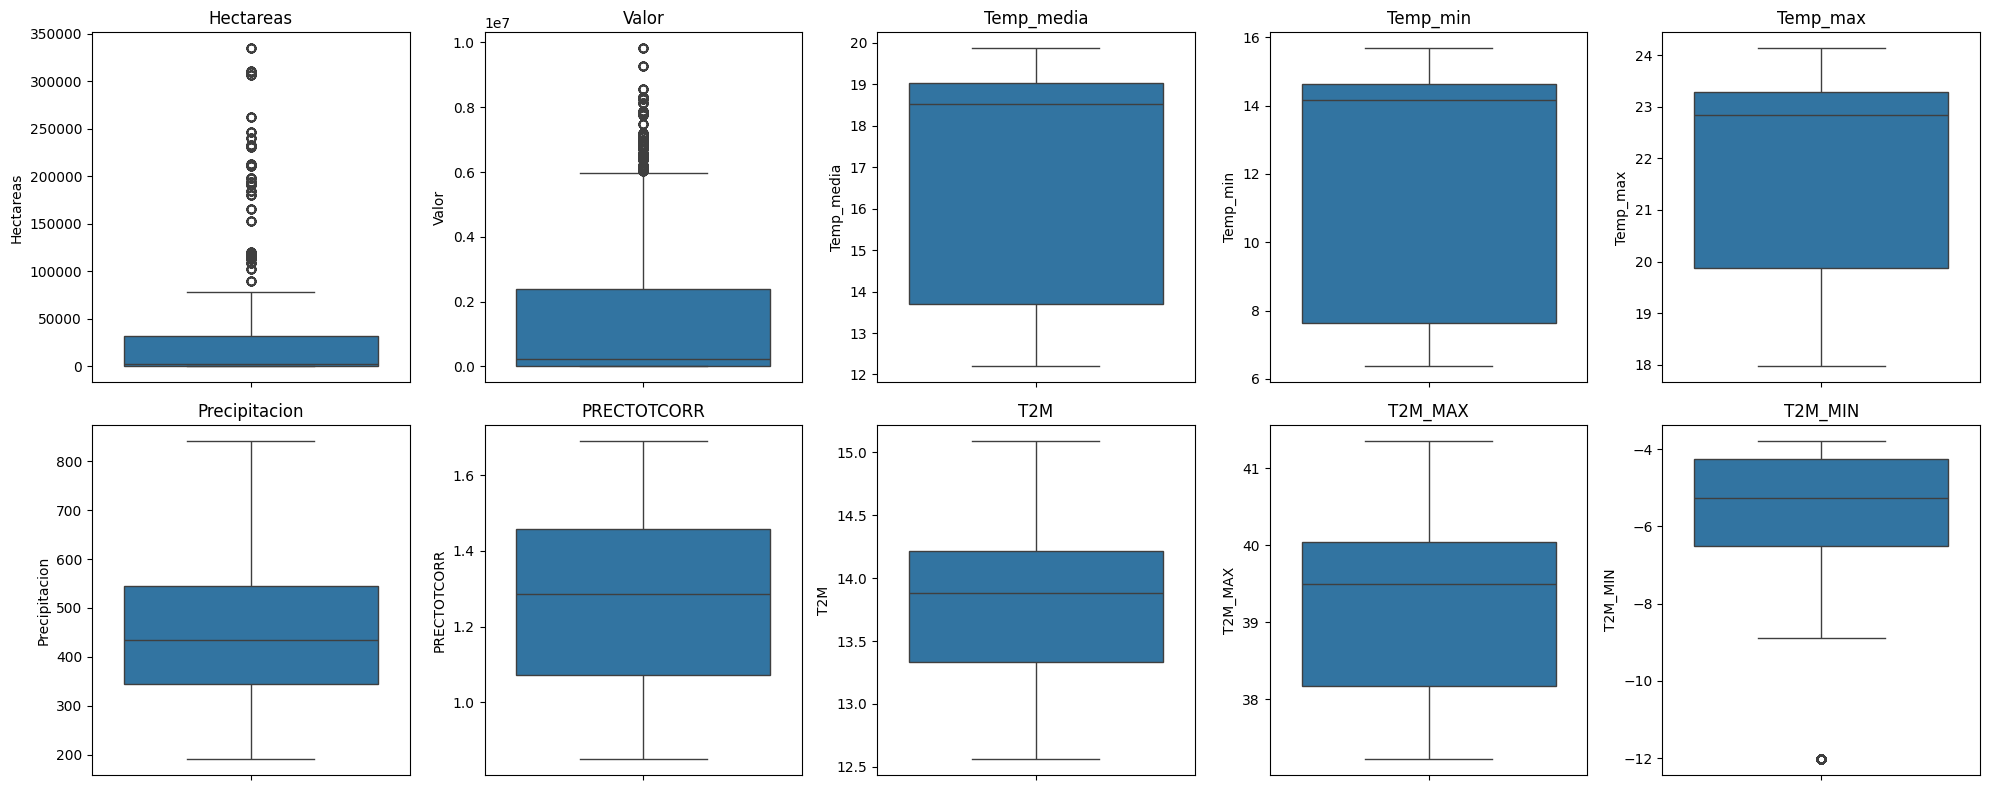

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(data=df_agric_clima, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Los boxplots revelan patrones consistentes con el análisis previo:

- **Hectáreas y Valor** presentan numerosos outliers en la parte superior, 
correspondientes a cultivos o provincias con superficies y producciones 
muy por encima de la media. Es coherente con el sesgo positivo extremo detectado.
- **Temperaturas AEMET** no muestran outliers porque la caja abarca los dos 
grupos climáticos (Valencia/Jaén vs Valladolid/Logroño), siendo los bigotes 
suficientemente amplios para contenerlos.
- **Variables NASA** tampoco presentan outliers al tener muy pocos valores únicos.
- **T2M_MIN** muestra un único punto outlier hacia temperaturas mínimas extremas, 
ya detectado previamente en la kurtosis.

In [23]:
iso = IsolationForest(contamination=0.05, random_state=42)

df_agric_clima["outlier"] = iso.fit_predict(df_agric_clima[numericas].fillna(0))

# -1 = outlier, 1 = normal
print(df_agric_clima["outlier"].value_counts())

outlier
 1    11856
-1      624
Name: count, dtype: int64


Se aplicó Isolation Forest con un umbral de contaminación del 5%, detectando 
624 observaciones atípicas sobre 12.480 filas totales.

Se decidió **mantener los outliers** en el dataset sin eliminarlos, ya que 
corresponden a valores agrícolas reales (provincias con alta concentración 
de cultivo) y no a errores de medición. Eliminarlos supondría perder 
información legítima y relevante para el modelo predictivo.

#### **Evolución temporal**

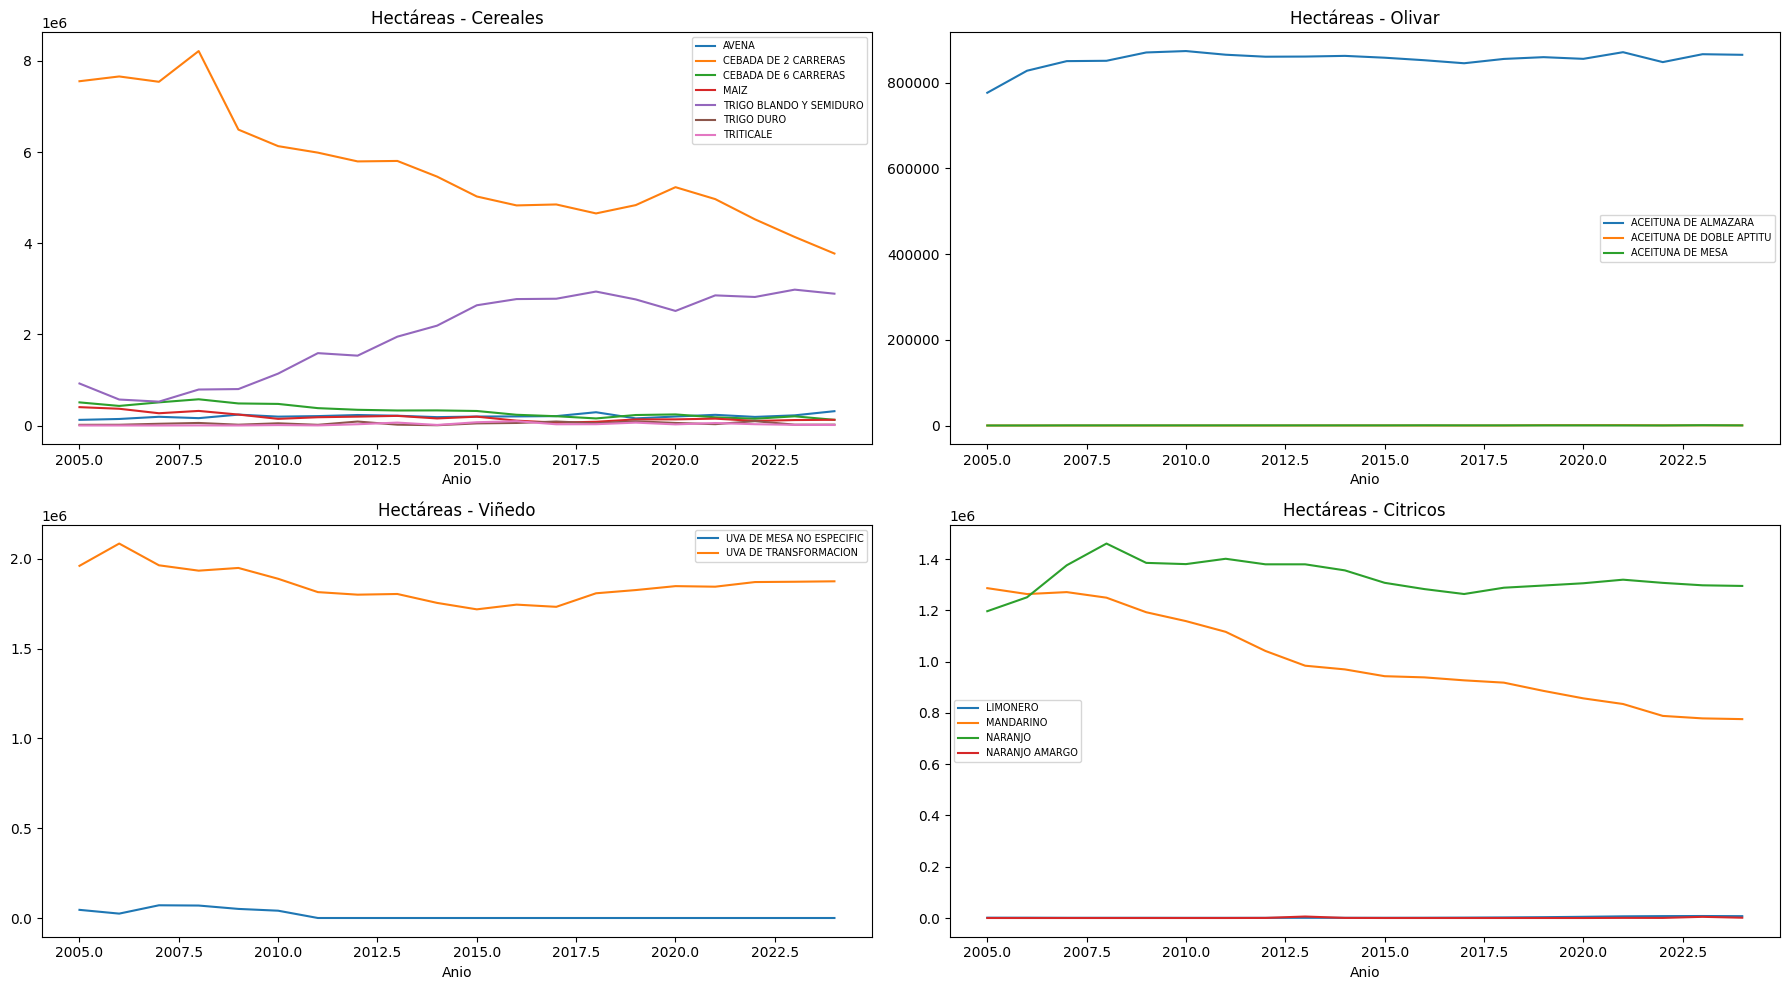

In [26]:
#Graficas de cultivos (ha)
grupos = {
    "Cereales": ["TRIGO DURO", "TRIGO BLANDO Y SEMIDURO", "CEBADA DE 2 CARRERAS", 
                 "CEBADA DE 6 CARRERAS", "AVENA", "MAIZ", "TRITICALE"],
    "Olivar": ["ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA"],
    "Viñedo": ["UVA DE MESA NO ESPECIFIC", "UVA DE TRANSFORMACION"],
    "Citricos": ["NARANJO", "MANDARINO", "LIMONERO", "NARANJO AMARGO"]
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, (grupo, cultivos) in enumerate(grupos.items()):
    df_agric_clima[df_agric_clima["Cultivo"].isin(cultivos)]\
        .groupby(["Anio", "Cultivo"])["Hectareas"].sum().unstack()\
        .plot(ax=axes[i], title=f"Hectáreas - {grupo}")
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

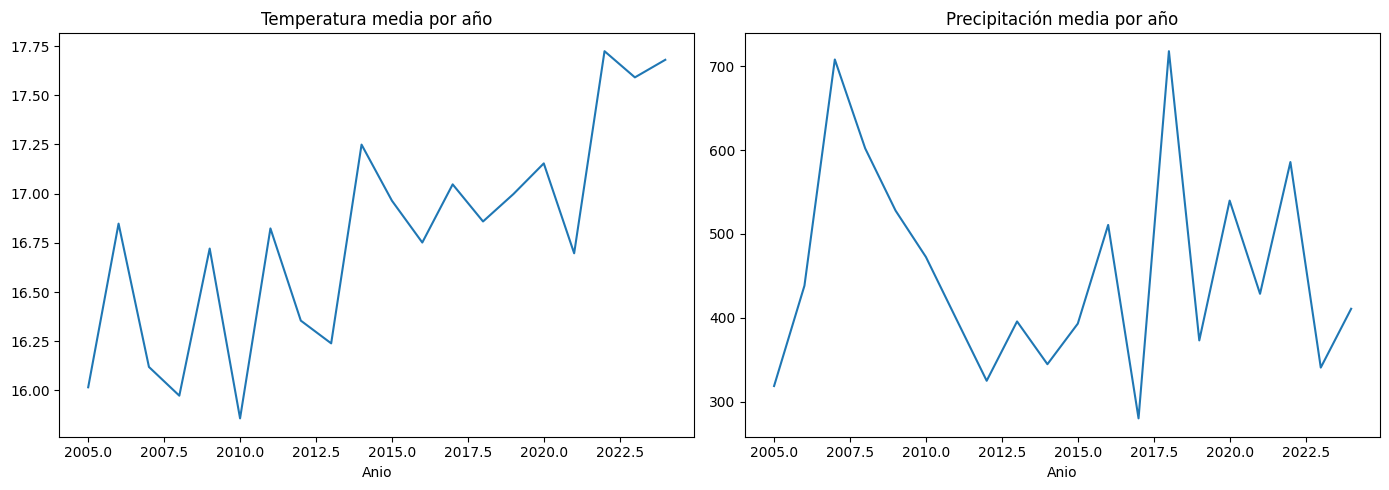

In [27]:
#Gráficas de temperaturas y precipitaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_agric_clima.groupby("Anio")["Temp_media"].mean().plot(
    ax=axes[0], title="Temperatura media por año"
)

df_agric_clima.groupby("Anio")["Precipitacion"].mean().plot(
    ax=axes[1], title="Precipitación media por año"
)

plt.tight_layout()
plt.show()

##### Cereales.
La cebada de 2 carreras domina en superficie pero muestra una caída pronunciada 
desde 2008, perdiendo casi la mitad de sus hectáreas en el período analizado. 
El trigo blando y semiduro gana terreno a partir de 2012 con una tendencia 
alcista sostenida. El resto de cereales se mantienen estables y con superficies 
mucho menores.

##### Olivar.
La aceituna de almazara domina de forma abrumadora y muestra un crecimiento 
sostenido a lo largo de todo el período, reflejo de la expansión del olivar 
intensivo en España. La aceituna de doble aptitud y de mesa tienen una presencia 
marginal.

##### Viñedo.
La uva de transformación concentra prácticamente toda la superficie, con una 
tendencia ligeramente bajista. La uva de mesa tiene una presencia casi testimonial.

##### Cítricos.
El naranjo es el cultivo dominante aunque con una ligera tendencia a la baja. 
El mandarino muestra una caída más pronunciada en el período. Limonero y 
Naranjo amargo tienen superficies marginales.

#### **Correlaciones**

In [29]:
#Correlación clima - hectárea
clima_vars = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion", 
              "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

correlaciones_hectareas = df_agric_clima[clima_vars + ["Hectareas"]].corr()["Hectareas"].drop("Hectareas").sort_values()

print(correlaciones_hectareas)

Temp_media      -0.234876
Temp_min        -0.234853
Temp_max        -0.230266
Precipitacion   -0.035787
T2M             -0.033511
T2M_MAX         -0.026789
PRECTOTCORR     -0.011169
T2M_MIN         -0.009394
Name: Hectareas, dtype: float64


In [30]:
#Correlación clima - valor
correlaciones_valor = df_agric_clima[clima_vars + ["Valor"]].corr()["Valor"].drop("Valor").sort_values()

print(correlaciones_valor)

T2M             -0.014669
T2M_MIN         -0.004439
Temp_max        -0.003444
T2M_MAX         -0.002022
Temp_media       0.000125
Temp_min         0.002087
Precipitacion    0.019733
PRECTOTCORR      0.030253
Name: Valor, dtype: float64


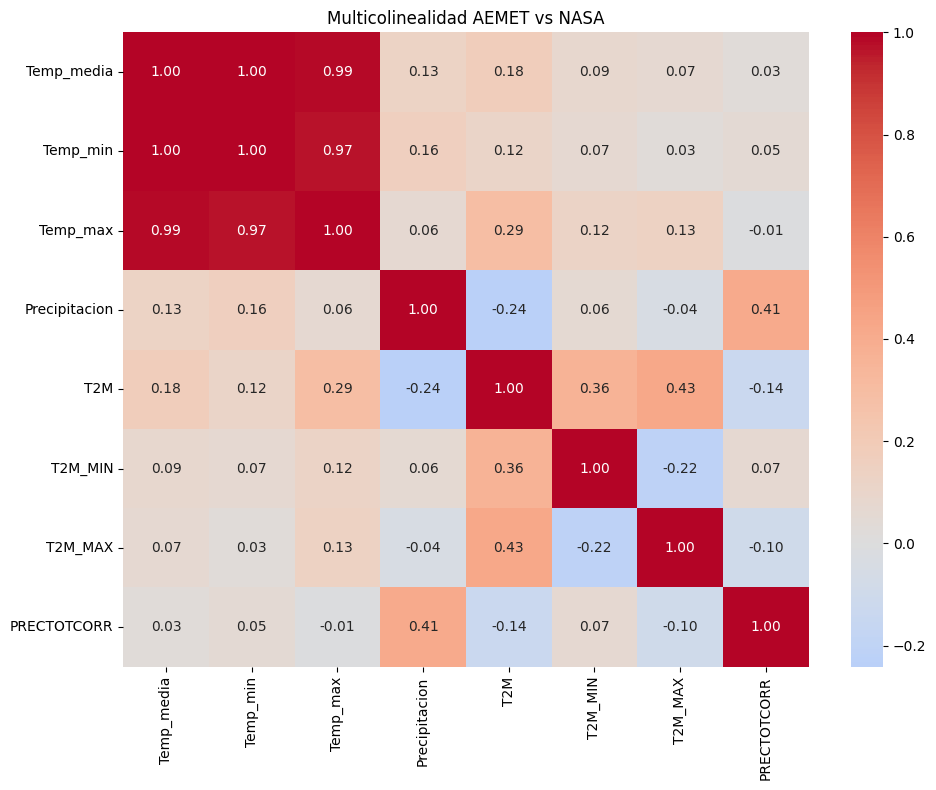

In [ ]:
#Correlación medidas AEMET y NASA
aemet_vars = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion"]
nasa_vars = ["T2M", "T2M_MIN", "T2M_MAX", "PRECTOTCORR"]

correlaciones_fuentes = df_agric_clima[aemet_vars + nasa_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlaciones_fuentes,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Multicolinealidad AEMET vs NASA")
plt.tight_layout()
plt.show()

In [32]:
correlacion_hect_valor = df_agric_clima[["Hectareas", "Valor"]].corr()
print(correlacion_hect_valor)

           Hectareas     Valor
Hectareas   1.000000 -0.000842
Valor      -0.000842  1.000000
